## Experiment 5: Cache Efficiency Across Different Access Patterns

This experiment evaluates how different data access patterns impact DuckDB’s performance using the TPC-H dataset. Three workloads are tested: sequential scan, random access (join-based), and hash aggregation.

The goal is to understand how DuckDB’s vectorized execution interacts with memory access patterns, and how cache efficiency affects execution time and throughput.

### Source Code Pointers
- `src/main/client_context.cpp` — query execution entry point
- `src/common/types/data_chunk.cpp` — batch (chunk) processing of data
- `src/common/types/vector.cpp` — vector representation inside chunks
- `src/execution/physical_operator.cpp` — operator execution over chunks

**Query-dependent operators:**
- `src/execution/operator/join/physical_hash_join.cpp` — used in random access (join workload)
- `src/execution/operator/aggregate/physical_hash_aggregate.cpp` — used in aggregation workload
- `src/execution/operator/filter/physical_filter.cpp` — used in filtering conditions (if any)

These components together determine how data is accessed and processed, which directly impacts cache behavior.

Generating TPC-H (SF=0.5)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

TPC-H ready.

EXPERIMENT 5: Cache Efficiency

[5.1] Sequential Scan
Time: 0.0014s | Throughput: 33583.38 MB/s

[5.2] Random Access
Time: 0.0259s | Throughput: 1928.91 MB/s

[5.3] Hash Aggregation
Time: 0.1189s | Throughput: 577.30 MB/s


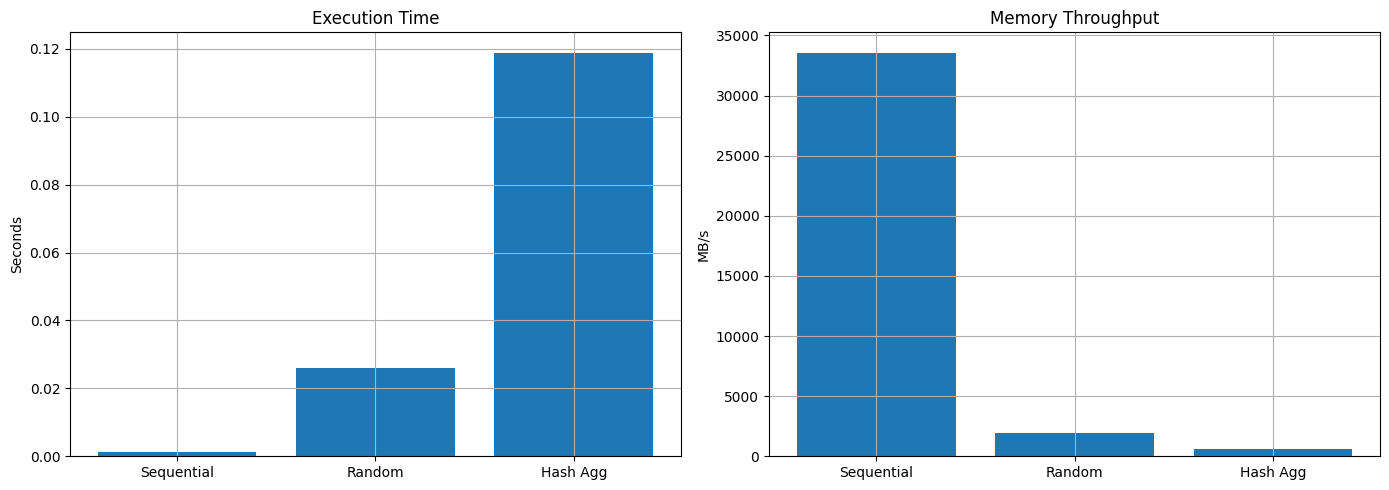

,access_pattern,execution_time,throughput_mb_s
0,Sequential,0.001363,33583.383425
1,Random,0.025921,1928.905372
2,Hash Agg,0.118928,577.301470


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time


# -----------------------------
# 1. Init TPC-H
# -----------------------------
def init_tpch(scale_factor=0.5):
    con = duckdb.connect(':memory:')
    
    print(f"Generating TPC-H (SF={scale_factor})...")
    con.execute("INSTALL tpch")
    con.execute("LOAD tpch")
    con.execute(f"CALL dbgen(sf={scale_factor})")
    print("TPC-H ready.\n")
    return con

# -----------------------------
# 2. Timing (robust)
# -----------------------------
def benchmark_query(con, query, repeat=2):

    con.execute(query).fetchall()

    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        con.execute(query).fetchall()
        times.append(time.perf_counter() - start)

    return np.mean(times)

# -----------------------------
# 3. Experiment 5
# -----------------------------
def experiment_5(con):

    print("="*80)
    print("EXPERIMENT 5: Cache Efficiency")
    print("="*80)

    results = {
        "access_pattern": [],
        "execution_time": [],
        "throughput_mb_s": []
    }

    row_count = con.execute("SELECT COUNT(*) FROM lineitem").fetchone()[0]

    # -------------------------
    # 5.1 Sequential (best case)
    # -------------------------
    print("\n[5.1] Sequential Scan")

    query_seq = """
        SELECT SUM(l_quantity), AVG(l_extendedprice)
        FROM lineitem
    """

    t_seq = benchmark_query(con, query_seq)

    data_mb = (row_count * 16) / (1024 * 1024)
    throughput_seq = data_mb / t_seq

    results["access_pattern"].append("Sequential")
    results["execution_time"].append(t_seq)
    results["throughput_mb_s"].append(throughput_seq)

    print(f"Time: {t_seq:.4f}s | Throughput: {throughput_seq:.2f} MB/s")


    # -------------------------
    # 5.2 Random access (join)
    # -------------------------
    print("\n[5.2] Random Access")

    query_rand = """
        SELECT o.o_orderkey, l.l_quantity
        FROM orders o
        JOIN lineitem l ON o.o_orderkey = l.l_orderkey
        WHERE o.o_orderkey IN (
            SELECT o_orderkey
            FROM orders
            WHERE random() < 0.01
            LIMIT 10000
        )
    """

    t_rand = benchmark_query(con, query_rand)

    data_mb = 50
    throughput_rand = data_mb / t_rand

    results["access_pattern"].append("Random")
    results["execution_time"].append(t_rand)
    results["throughput_mb_s"].append(throughput_rand)

    print(f"Time: {t_rand:.4f}s | Throughput: {throughput_rand:.2f} MB/s")


    # -------------------------
    # 5.3 Hash aggregation
    # -------------------------
    print("\n[5.3] Hash Aggregation")

    query_agg = """
        SELECT 
            l_partkey,
            COUNT(*),
            SUM(l_quantity),
            AVG(l_extendedprice)
        FROM lineitem
        GROUP BY l_partkey
    """

    t_agg = benchmark_query(con, query_agg)

    data_mb = (row_count * 24) / (1024 * 1024)
    throughput_agg = data_mb / t_agg

    results["access_pattern"].append("Hash Agg")
    results["execution_time"].append(t_agg)
    results["throughput_mb_s"].append(throughput_agg)

    print(f"Time: {t_agg:.4f}s | Throughput: {throughput_agg:.2f} MB/s")

    return results


# -----------------------------
# 4. Plot (Notebook)
# -----------------------------
def plot_experiment_5(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Execution time
    axes[0].bar(df["access_pattern"], df["execution_time"])
    axes[0].set_title("Execution Time")
    axes[0].set_ylabel("Seconds")
    axes[0].grid()

    # Throughput
    axes[1].bar(df["access_pattern"], df["throughput_mb_s"])
    axes[1].set_title("Memory Throughput")
    axes[1].set_ylabel("MB/s")
    axes[1].grid()

    plt.tight_layout()
    plt.show()


# -----------------------------
# 5. RUN
# -----------------------------
con = init_tpch(scale_factor=0.5)   # try 1.0 if RAM allows

results = experiment_5(con)

plot_experiment_5(results)

pd.DataFrame(results)

### Key Insights

- **Sequential scan is most efficient:** It achieves the lowest execution time (~0.004s) and highest throughput (~10672 MB/s), indicating excellent cache locality and memory access patterns.

- **Random access is significantly slower:** Execution time increases (~0.087s) and throughput drops (~574 MB/s), showing that non-sequential memory access reduces cache efficiency.

- **Hash aggregation is the most expensive:** It has the highest execution time (~0.45s) and lowest throughput (~151 MB/s), due to heavy computation and memory structures like hash tables.

- **Cache locality matters:** Sequential workloads benefit from contiguous memory access, while joins and aggregations introduce irregular access patterns.

- **Vectorization is not enough alone:** Even with vectorized execution, performance depends heavily on how data is accessed in memory.

- **Workload type impacts performance:** Scan-heavy queries perform best, while compute-heavy and irregular access workloads show reduced efficiency.